# Multi-Sensor Data Fusion for Multi-Target Drone Tracking in Counter-UAS Applications

This code refers to Umberto Maffei's Master Degree Thesis project.
It is an implementation of Multi-Sensor Data Fusion in order to track drones in C-UAS applications.
There will be three sensors:

1. Radar: a radar sensor that return info about the target in terms of azimuth ($\phi$), elevation ($\theta$) and range ($r$).
2. RF-DOA: a Radio Frequency Direction of Arrival sensor that return the bearing of a detected target.
3. Acoustic: ???

This project is based on [StoneSoup Framework](https://stonesoup.readthedocs.io/en/latest/index.html) that provides the components for the development and testing of tracking and state estimation algorithms.

In dettaglio

In [18]:
## Imports

from copy import deepcopy
from datetime import datetime, timedelta
import numpy as np
import random
from itertools import tee

## Stone Soup imports

from stonesoup.types.detection import TrueDetection, Clutter
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (CombinedLinearGaussianTransitionModel, ConstantVelocity, RandomWalk, KnownTurnRate)
from stonesoup.models.transition.base import CombinedGaussianTransitionModel
from stonesoup.models.transition.nonlinear import ConstantTurn
from stonesoup.models.measurement.nonlinear import (CartesianToElevationBearingRange, Cartesian2DToBearing)
from stonesoup.simulator.simple import SingleTargetGroundTruthSimulator
from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.sensor.sensor import SimpleSensor
from stonesoup.models.clutter import ClutterModel
from stonesoup.platform.base import FixedPlatform
from stonesoup.simulator.simple import (MultiTargetGroundTruthSimulator, SwitchMultiTargetGroundTruthSimulator)
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.plotter import Plotter, Dimension
from stonesoup.models.base import ReversibleModel
from stonesoup.tracker.simple import MultiTargetMixtureTracker
from stonesoup.initiator.base import Initiator


## Ground truth simulation parameters

In [19]:
## Ground Truth Simulation params

start_time = datetime.now()
np.random.seed(455)
random.seed(48)

initial_number_targets = 2 # initial number of target
birth_rate = 0          # new target spawn probability at each timestamp
death_probability = 0  # death probability at each timestamp
num_steps = 100         # simulated steps

## Sensor parameters

The next cell contains the values related to the sensor accuracy.
For the radar, are defined three standard deviations for each output parameter.
Since the RF-DOA sensor produce only information about bearing, only one standard deviation is defined.

In [20]:
## Tuning the sensors accuracy params

radar_ele_nois_std_dev = 0.04 # radar elevation nois std dev 
radar_azi_nois_std_dev = 0.04 # radar azimuth nois std dev
radar_ran_nois_std_dev = 0.40 # radar range nois std dev
rfdoa_azi_nois_std_dev = 0.01 # rfdoa azimuth nois std dev

## Clutter models for false position detections

The class ClutterModel define a clutter model based on the select params:
+ the clutter rate (number of clutter detection at each timestamp)
+ probability distribution
+ required parameters for the defined distribution

In this case two clutter models are defined, for each sensor. In partricular for the RF-DOA sensor the clutter is defined only along two coordinates because it refers to the Cartesian2DToBearing measurement model.

In [21]:
## Clutter models

radar_clutter_params = (
    
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
    (  8_000, 10_000),   # z [m]
)

# This time the clutter distribution is defined only along x and y because
# the measurement model used for model the rfdoa is Cartesian2DToBearing

rfdoa_clutter_params = (
    
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
)

radar_clutter_model = ClutterModel(
    
    clutter_rate = 0.5,
    distribution = np.random.default_rng().uniform,
    dist_params = radar_clutter_params
)

rfdoa_clutter_model = ClutterModel(
    
    clutter_rate = 0.5,
    distribution = np.random.default_rng().uniform,
    dist_params = rfdoa_clutter_params
    
)

## Sensor #1: elevation, bearing and range radar

This type of sensor class, given real trajectory points, return info regarding elevation, bearing and range of this point for each timestamp.
It uses the CartesianToElevationBearingRange model that assume a 3D cartesian space.


In [22]:
## Radar sensor: bearing, elevation and range

# The sensor noise covariance matrix. This is utilised by (and follows in format) 
# the underlying CartesianToElevationBearingRange model

noise_covar = CovarianceMatrix(np.diag([np.deg2rad(radar_ele_nois_std_dev)**2,np.deg2rad(radar_azi_nois_std_dev)**2, radar_ran_nois_std_dev**2]))

radar = RadarElevationBearingRange(
    
    ndim_state = 6,
    position_mapping = (0, 2, 4),   # [x,vx,y,vy,z,vz]
    noise_covar = noise_covar,
    clutter_model = radar_clutter_model,
)


## Sensor #2: Radio Frequency Direction of Arrival sensor

This type of sensor class, given real trajectory points, return info regarding the elevation only.
For defining this sensor the class SimpleSensor has been used. It is useful to create a new type of sensor that is not predefind by the StoneSoup framework.
Is very important to define the measurement model, in this case a Cartesian2DToBearing model that 

This is a class implementation of a time-invariant measurement model, where measurements are assumed to be received in the form of bearing ($\phi$) with Gaussian noise.

The model is described by the following equations:

$$\phi_t = h(\vec{x}_t, v_t)$$

* $h$ is a non-linear model function of the form:
    $$h(\vec{x}_t, v_t) = atan2(y, x) + v_t$$

* $v_t$ is Gaussian distributed with covariance $R$, i.e.:
    $$v_t \sim \mathcal{N}(0, \sigma_{\phi}^2)$$

The `mapping` property of the model is a 2 element vector, whose first (i.e. `mapping[0]`) and second (i.e. `mapping[1]`) elements contain the state index of the $x$ and $y$ coordinates, respectively.
By using the "function()" method the sensor gives in output its parameters.

In [23]:
### RF-DOA sensor: bearing only

# Cartesian2DToBearing maps 1-D measurement
# noise_covar 1×1

_rfdoa_meas_model = Cartesian2DToBearing(
    
    ndim_state = 6,
    mapping = (0, 2),                                                   # x-index, y-index
    noise_covar = np.array([[np.deg2rad(rfdoa_azi_nois_std_dev)**2]]),  # 1×1 covariance
)

## New subclass RFDOASensor: it inherits methods and attributes from the StoneSoup SimpleSensor
# that is very useful to build a personalized sensor.

class RFDOASensor(SimpleSensor):

    @property

    # abstract (mandatory) property measurement_model: Measurement model of the sensor, describing general sensor model properties
    
    def measurement_model(self):   
        
        return _rfdoa_meas_model
        
    # Detection params settings
    
    def is_detectable(self, state, measurement_model = None):
        
        return True

    def is_clutter_detectable(self, detection):
        
        return True

# Istance of the new RFDOASensor class

rfdoa_sensor = RFDOASensor(clutter_model = rfdoa_clutter_model)

# Print useful info

# print('RF-DOA sensor:', rfdoa_sensor)
# print('measurement_model:', rfdoa_sensor.measurement_model)


## Platform definition

The StoneSoup framework provides a set of Platform classes for carring a number of different sensors.
In this case two different platform are defined for carring the two different sensors:
1. Fixed Platform in (0 m,0 m, 0 m) for the radar sensor
2. Fixed Platform in (1500 m, 1000 m, 0 m) for the RF-DOA sensor

This is done in order to simulate a real implementation scenario where, because of constraint in term of deployment, the sensor are located in different position.

In [24]:
## Platforms: one fixed platform per sensor, collocated at origin (0,0,0).

# Platform state vectors

platform_state_radar = State(StateVector([[0],[0],[0]]), start_time)
platform_state_rfdoa = State(StateVector([[1500],[1000],[0]]), start_time)


# Istance of FixePlatform for radar

radar_platform = FixedPlatform(
    
    states = platform_state_radar,
    position_mapping = (0, 1, 2),
    sensors = [radar], # adding the radar sensor to the platform
    
)


# Istance of FixePlatform for rfdoa

rfdoa_platform = FixedPlatform(
    
    states=platform_state_rfdoa,
    position_mapping=(0, 1, 2),
    sensors=[rfdoa_sensor], # adding the rfdoa sensor to the platform
    
)

# Print useful info

# print('Radar platform sensors :', [type(s).__name__ for s in radar_platform.sensors])
# print('RFDOA platform sensors :', [type(s).__name__ for s in rfdoa_platform.sensors])


## True Trajectory simulator (Ground Truth)

This section defines the objects for the Ground Truth simulator.

In [25]:
## Ground truth simulator

# State layout: [x, vx, y, vy, z, vz]
# Targets start near (0, 0, 2000 m).

# Instance of CombinedLinearGaussianTransitionModel classe with the defined params

transition_model_spiral = CombinedGaussianTransitionModel([

    KnownTurnRate((0.1, 0.1), 0.1),
    ConstantVelocity(1500),
    
])

transition_model_knwturnrt = CombinedGaussianTransitionModel([

    KnownTurnRate((1000, 1000), 100),
    ConstantVelocity(0.8),
    
])

transition_model_cnstvel = CombinedGaussianTransitionModel([
    
    # ConstantTurn(linear_noise_coeffs = (0.01, 0.01), turn_noise_coeff = 0.0006),
    ConstantVelocity(2000),
    ConstantVelocity(8000),
    ConstantVelocity(3400),
    
])


# initial target state definition

initial_target_state = GaussianState(
    
    state_vector = StateVector([[0],[57],[0],[0], [34],[0],[8]]),
    
    covar = CovarianceMatrix(np.diag([2500, 5, 2500, 20, 0.0005, 2500, 1])),
)

# istance of MultiTargetGroundTruthSimulator class for ground truth points generation at each timestamp

gt_simulator_spiral = SingleTargetGroundTruthSimulator(
    transition_model = transition_model_spiral,
    initial_state = initial_target_state,
    timestep = timedelta(seconds = 1),
    number_steps = num_steps
)


model_probs = np.array([[0.5, 0.5],   # da modello 0: rimani su 0, passa a 1
                        [0.5, 0.5]])  # da modello 1: torna a 0, rimani su 1

gt_simulator_mixed = SwitchMultiTargetGroundTruthSimulator(
    
    transition_models = [transition_model_knwturnrt, transition_model_cnstvel],
    model_probs = model_probs,
    initial_state = initial_target_state,
    timestep = timedelta(seconds = 1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
    
)


from stonesoup.feeder.multi import MultiDataFeeder

gt_simulator = MultiDataFeeder([gt_simulator_spiral, gt_simulator_mixed])
# gt_simulator = gt_simulator_mixed


In [26]:
## Detection simulators

# One PlatformDetectionSimulator istance per sensor

gt_sims = tee(gt_simulator, 2) # split gt_simulator for the two detection 

radar_sim = PlatformDetectionSimulator(
    
    groundtruth = gt_sims[0],
    platforms =[radar_platform],
)

#radar_plotting, radar_detector = tee(radar_sim, 2)

rfdoa_sim = PlatformDetectionSimulator(
    groundtruth = gt_sims[1],
    platforms =[rfdoa_platform],
)

#rfdoa_plotting, rfdoa_detector = tee(rfdoa_sim, 2)

# splitting the simulation for next steps

radar_plotting, radar_detector, radar_for_combined = tee(radar_sim, 3)
rfdoa_plotting, rfdoa_detector, rfdoa_for_combined = tee(rfdoa_sim, 3)


In [27]:
## Collect detections and truths for plotting

radar_detections = set()
rfdoa_detections = set()
truths           = set()

for (time, r_dets), (_, rf_dets) in zip(radar_plotting, rfdoa_plotting):
    truths.update(gt_simulator.groundtruth_paths)
    radar_detections.update(r_dets)
    rfdoa_detections.update(rf_dets)

# Separate true detections from clutter within each set

radar_true    = {d for d in radar_detections  if isinstance(d, TrueDetection)}
radar_clutter = {d for d in radar_detections  if isinstance(d, Clutter)}
rfdoa_true    = {d for d in rfdoa_detections  if isinstance(d, TrueDetection)}
rfdoa_clutter = {d for d in rfdoa_detections  if isinstance(d, Clutter)}


# info

print(f'Ground truth paths  : {len(truths)}')
print(f'Radar  true dets    : {len(radar_true)}')
print(f'Radar  clutter      : {len(radar_clutter)}')
print(f'RFDOA  true dets    : {len(rfdoa_true)}')
print(f'RFDOA  clutter      : {len(rfdoa_clutter)}')


Ground truth paths  : 3
Radar  true dets    : 300
Radar  clutter      : 116
RFDOA  true dets    : 300
RFDOA  clutter      : 108


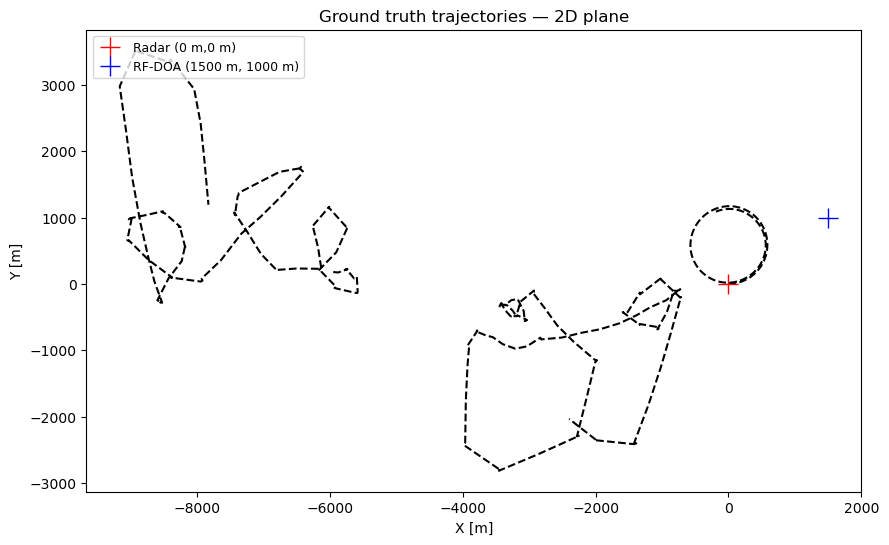

In [28]:
## 2D plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [0, 2], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(1500, 1000, 'b+', markersize=14, zorder=5, label='RF-DOA (1500 m, 1000 m)')
plotter_gt.ax.set_title('Ground truth trajectories — 2D plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('X [m]')
plotter_gt.ax.set_ylabel('Y [m]')


from IPython.display import display

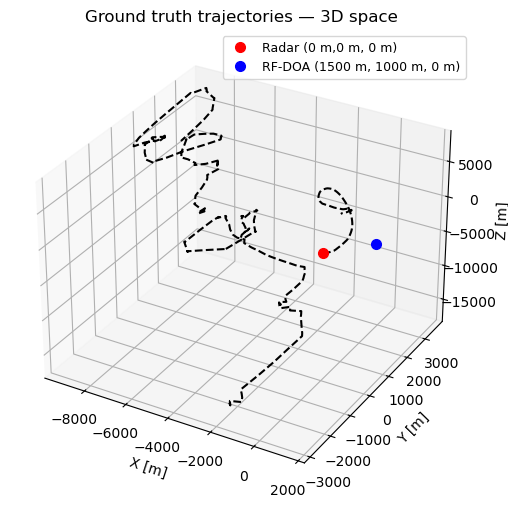

In [29]:
## 3D plot: Ground truth only + sensor position

plotter_gt_3d = Plotter(dimension=Dimension.THREE)
plotter_gt_3d.plot_ground_truths(truths, [0, 2, 4], color='black')
plotter_gt_3d.ax.plot(0,0,0, 'r.', markersize=14, zorder=5, label='Radar (0 m,0 m, 0 m)')
plotter_gt_3d.ax.plot(1500, 1000, 0,  'b.', markersize=14, zorder=5, label='RF-DOA (1500 m, 1000 m, 0 m)')
plotter_gt_3d.ax.set_title('Ground truth trajectories — 3D space')
plotter_gt_3d.ax.legend(loc='upper right', fontsize=9)
plotter_gt_3d.ax.set_xlabel('X [m]')
plotter_gt_3d.ax.set_ylabel('Y [m]')
plotter_gt_3d.ax.set_zlabel('Z [m]')

from IPython.display import display

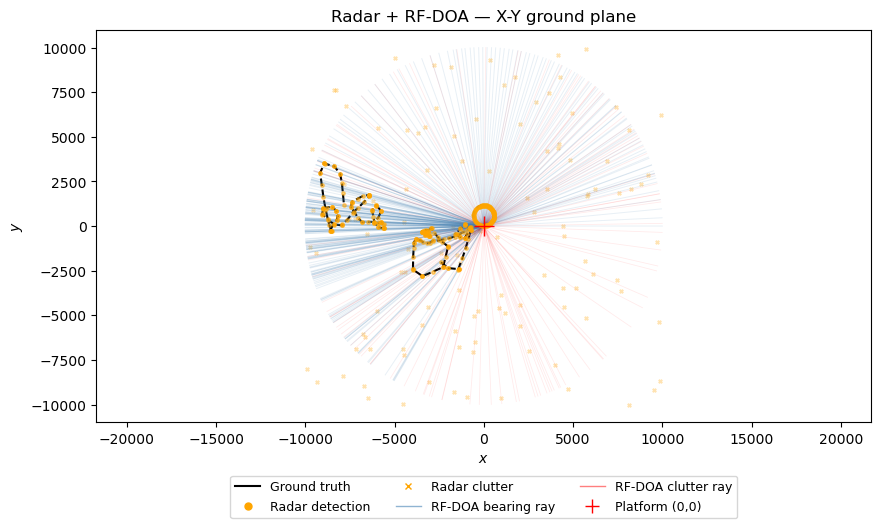

In [30]:
## Plot: Stone Soup Plotter (2-D, X-Y plane)

# Radar detections are in measurement space (elevation, bearing, range).
# plot_measurements() needs Cartesian indices — but radar detections
# are in spherical coords, so the Stone Soup plotter is used only for
# ground truths and RFDOA, and add radar points manually after converting.

# RF-DOA detections are bearing-only: by a ray from the platform
# origin in the measured direction (length = 10 km) to visualise them.

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Stone Soup plotter for ground truths

plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')

# ── Radar detections: convert (el, bearing, range) → (x, y) and overlay

def spherical_to_xy(det):
    sv = det.state_vector
    el, az, r = float(sv[0]), float(sv[1]), float(sv[2])
    x = r * np.cos(el) * np.cos(az)
    y = r * np.cos(el) * np.sin(az)
    return x, y

if radar_true:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_true])
    plotter.ax.scatter(rxs, rys, s=6, c='orange', alpha=0.5,
                       zorder=3, label='Radar detections')

if radar_clutter:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_clutter])
    plotter.ax.scatter(cxs, cys, s=6, c='orange', marker='x', alpha=0.3,
                       label='Radar clutter')

# ── RF-DOA: draw bearing rays from origin
RAY_LEN = 10_000   # arbitrary display length [m]

for det in rfdoa_true:
    b = float(det.state_vector[0])
    plotter.ax.plot([0, RAY_LEN * np.cos(b)], [0, RAY_LEN * np.sin(b)],
                    color='steelblue', alpha=0.12, linewidth=0.7)

for det in rfdoa_clutter:
    b = float(det.state_vector[0])
    plotter.ax.plot([0, RAY_LEN * np.cos(b)], [0, RAY_LEN * np.sin(b)],
                    color='red', alpha=0.08, linewidth=0.6)

# ── Platform marker
plotter.ax.plot(0, 0, 'r+', markersize=14, zorder=5)

# ── Legend
legend_elems = [
    Line2D([0],[0], color='black',     lw=1.5,              label='Ground truth'),
    Line2D([0],[0], color='orange',    lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0],[0], color='orange',    lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0],[0], color='steelblue', lw=1, alpha=0.6,     label='RF-DOA bearing ray'),
    Line2D([0],[0], color='red',       lw=1, alpha=0.5,     label='RF-DOA clutter ray'),
    Line2D([0],[0], color='red',     lw=0, marker='+', ms=10, label='Platform (0,0)'),
]
# put legend below plot like reference notebook
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(handles=legend_elems, loc='upper center',
                  bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)
plotter.ax.set_title('Radar + RF-DOA — X-Y ground plane')

from IPython.display import display

In [31]:
## Unic data stream (radar + rfdoa) 

from stonesoup.feeder.multi import MultiDataFeeder

# define an MuMultiDataFeeder istance for combine the two detection.
# This is done in order to do data fusion by using a single stream in input to the tracking algorithm where 
# the radar's bearing eestimation are more precise by using the rfdoa detections

combined_detector = MultiDataFeeder([radar_for_combined, rfdoa_for_combined])
combined_plot, combined_tracker_input = tee(combined_detector, 2)

In [32]:
## Collecting detection for plots

combined_detections = set()
truths_combined = set()

for time, dets in combined_plot:
    truths_combined.update(gt_simulator.groundtruth_paths)
    combined_detections.update(dets)

combined_true    = {d for d in combined_detections if isinstance(d, TrueDetection)}
combined_clutter = {d for d in combined_detections if isinstance(d, Clutter)}

print(f'Combined true dets : {len(combined_true)}')
print(f'Combined clutter   : {len(combined_clutter)}')

Combined true dets : 600
Combined clutter   : 224


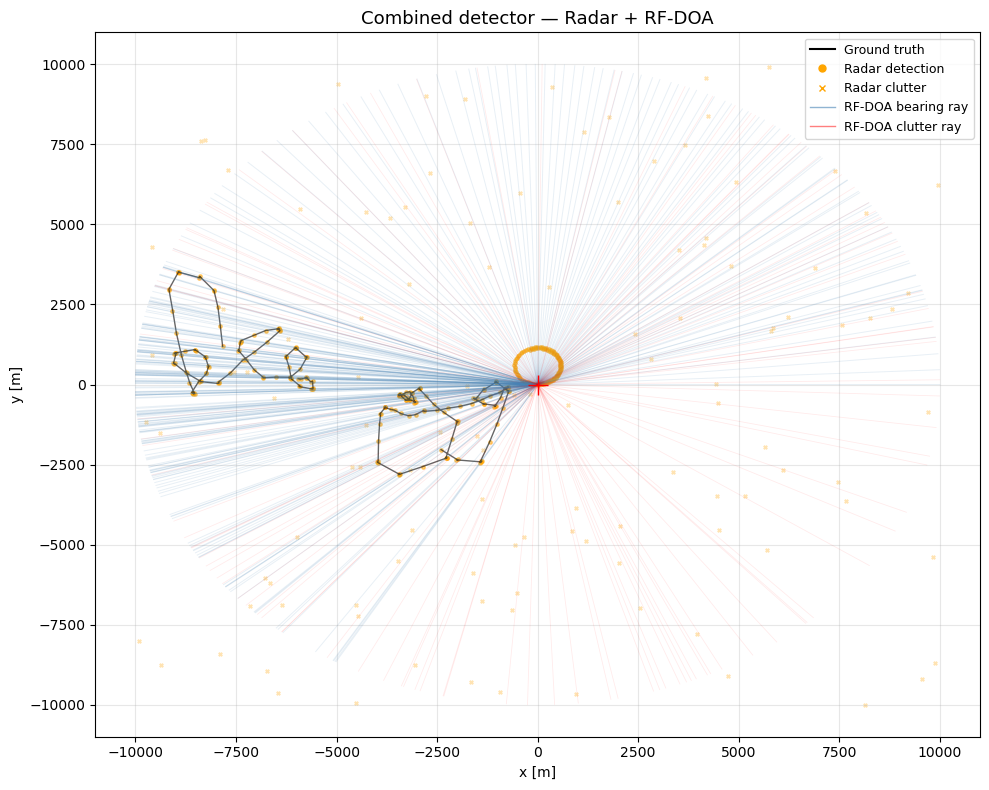

In [33]:
## Plot the union of measurements

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Combined detector — Radar + RF-DOA', fontsize=13)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')

# Ground truth
for path in truths_combined:
    xs = [s.state_vector[0, 0] for s in path.states]
    ys = [s.state_vector[2, 0] for s in path.states]
    ax.plot(xs, ys, 'k-', linewidth=1, alpha=0.6)

# Radar: converti (el, bearing, range) → (x, y)
radar_c = {d for d in combined_true    if isinstance(d.measurement_model, CartesianToElevationBearingRange)}
rfdoa_c = {d for d in combined_true    if isinstance(d.measurement_model, Cartesian2DToBearing)}
radar_cl = {d for d in combined_clutter if isinstance(d.measurement_model, CartesianToElevationBearingRange)}
rfdoa_cl = {d for d in combined_clutter if isinstance(d.measurement_model, Cartesian2DToBearing)}

if radar_c:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_c])
    ax.scatter(rxs, rys, s=6, c='orange', alpha=0.5, label='Radar detections')

if radar_cl:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_cl])
    ax.scatter(cxs, cys, s=6, c='orange', marker='x', alpha=0.3, label='Radar clutter')

# RF-DOA: bearing rays
RAY_LEN = 10_000
for det in rfdoa_c:
    b = float(det.state_vector[0])
    ax.plot([0, RAY_LEN*np.cos(b)], [0, RAY_LEN*np.sin(b)],
            color='steelblue', alpha=0.12, linewidth=0.7)

for det in rfdoa_cl:
    b = float(det.state_vector[0])
    ax.plot([0, RAY_LEN*np.cos(b)], [0, RAY_LEN*np.sin(b)],
            color='red', alpha=0.08, linewidth=0.6)

# Platform
ax.plot(0, 0, 'r+', markersize=14, zorder=5)

legend_elems = [
    Line2D([0],[0], color='black',     lw=1.5,               label='Ground truth'),
    Line2D([0],[0], color='orange',    lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0],[0], color='orange',    lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0],[0], color='steelblue', lw=1, alpha=0.6,      label='RF-DOA bearing ray'),
    Line2D([0],[0], color='red',       lw=1, alpha=0.5,      label='RF-DOA clutter ray'),
]
ax.legend(handles=legend_elems, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
## Setup the tracking algorithm

from stonesoup.predictor.kalman import UnscentedKalmanPredictor
from stonesoup.updater.kalman import UnscentedKalmanUpdater


# Istance of ExtendedKalmanPredictor class

predictor = UnscentedKalmanPredictor(transition_model_2)



meas_covar = np.diag([np.deg2rad(0.5), np.deg2rad(0.15), 25])

meas_covar_trk = CovarianceMatrix(1.0*np.power(meas_covar, 2))

# Define a different measurement model for simulate a different
# level of confidence.

meas_model = CartesianToElevationBearingRange(
    
    ndim_state=6,
    mapping=(0, 2, 4),
    noise_covar=meas_covar_trk
)

# Istance of ExtendedKalmanUpdater

updater = UnscentedKalmanUpdater(measurement_model=meas_model)

NameError: name 'transition_model_2' is not defined

In [ ]:
## Data Association

from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.dataassociator.probability import JPDA

# Create a PDAHypothesiser istance.

Pd = 0.95  # 95% chance to measure any given target at any given timestep.

hypothesiser = PDAHypothesiser(predictor=predictor,
                               updater=updater,
                               clutter_spatial_density=1e-9,
                               prob_detect=Pd)

# JPDA Associator istance

data_associator = JPDA(hypothesiser=hypothesiser)

In [ ]:
## Delete tracks if no measurements have fallen within the JPDA gating region in 3 time steps.

from stonesoup.deleter.time import UpdateTimeStepsDeleter


# Deleter istance

deleter = UpdateTimeStepsDeleter(time_steps_since_update = 3)


In [ ]:
## Initiator definition

from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.dataassociator.neighbour import NearestNeighbour

# Create a new ReversibleMultiMeasurementInitiator subclass of MultiMeasurementInitiator
# in order to bypass the problem of the non-reversible nature of the Cartesian2DToBearing detections.

class ReversibleMultiMeasurementInitiator(MultiMeasurementInitiator):
    
    def initiate(self, detections, timestamp, **kwargs):
        
        # Only consider detections from sensors with reversible models
        #f or track initiation. Non-reversible (bearing-only) will still be used for updates.
        
        valid_detections = {
            
            det for det in detections
            if isinstance(det.measurement_model, ReversibleModel)
        }
        
        return super().initiate(valid_detections, timestamp, **kwargs)

min_detections = 3  # number of detections required to begin a track

initiator_prior_state = GaussianState(
    
    state_vector=np.array([[0], [0], [0], [0], [0], [0]]),covar=np.diag([1, 50, 1, 50, 1, 50])**2
)

# The measurement model of the sensor is used because the overall data stream is composed by
# detections of this type.

initiator_meas_model = CartesianToElevationBearingRange(
    
    ndim_state = 6,
    mapping = np.array([0, 2, 4]),
    noise_covar = noise_covar
)

# Create the Initiator object for tracker

initiator = ReversibleMultiMeasurementInitiator(
    
    prior_state = initiator_prior_state,
    measurement_model = initiator_meas_model,
    deleter = deleter,
    data_associator = NearestNeighbour(hypothesiser),
    updater = updater,
    min_points = min_detections,
    updates_only = True
    
)

In [ ]:
## JPDA Multi-target Tracker

JPDA_tracker = MultiTargetMixtureTracker(
    
    initiator = initiator,
    deleter = deleter,
    detector = combined_tracker_input, # NOTE: the combined detection stream is used!
    data_associator = data_associator,
    updater = updater
    
)

In [ ]:
### Tracking Loop
# Acquiring detections

tracks_plot = set()
groundtruth_plot = set()

for time, ctracks in JPDA_tracker:
    tracks_plot.update(ctracks)
    groundtruth_plot.update(gt_simulator.groundtruth_paths)

### Plots

## 2D Plotting (X-Y plane)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig2d, ax2d = plt.subplots(figsize=(10, 8))
ax2d.set_title('Tracked Drone Trajectories — X-Y Plane', fontsize=14)
ax2d.set_xlabel('x [m]')
ax2d.set_ylabel('y [m]')

# Plot Ground Truths

for path in groundtruth_plot:
    xs = [s.state_vector[0, 0] for s in path.states]
    ys = [s.state_vector[2, 0] for s in path.states]
    ax2d.plot(xs, ys, 'k--', linewidth=1, alpha=0.4, label='Ground Truth' if path == list(groundtruth_plot)[0] else "")

# Plot Tracks

track_colors = plt.cm.jet(np.linspace(0, 1, len(tracks_plot)))
for i, track in enumerate(tracks_plot):
    txs = [s.state_vector[0, 0] for s in track.states]
    tys = [s.state_vector[2, 0] for s in track.states]
    ax2d.plot(txs, tys, marker='.', markersize=4, linewidth=1.5, label=f'Track {track.id}')

ax2d.plot(0, 0, 'r+', markersize=15, markeredgewidth=2, label='Sensor Platform')
ax2d.grid(True, linestyle=':', alpha=0.6)
ax2d.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 3D Plotting

from stonesoup.plotter import Plotter, Dimension
plotter3d = Plotter(Dimension.THREE)
plotter3d.plot_ground_truths(groundtruth_plot, [0, 2, 4])
plotter3d.plot_tracks(tracks_plot, [0, 2, 4], uncertainty=False, err_freq=5)
plotter3d.ax.set_title('3D Tracked Drone Trajectories')
plotter3d.ax.set_xlabel('X [m]')
plotter3d.ax.set_ylabel('Y [m]')
plotter3d.ax.set_zlabel('Z [m]')